Import the necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import joblib

Load and inspect data

In [3]:
df = pd.read_csv('../data/Time Management and Productivity Insights.csv')

In [4]:
df.head()

,User ID,Age,Daily Work Hours,Daily Leisure Hours,Daily Exercise Minutes,Daily Sleep Hours,Productivity Score,Screen Time (hours),Commute Time (hours)
0,1,62,5.5,4.0,92,5.2,55,3.7,0.6
1,2,32,4.8,3.5,6,8.8,69,7.2,1.9
2,3,52,3.4,2.1,75,7.2,68,3.3,2.0
3,4,50,9.4,4.0,53,6.9,91,7.5,1.6
4,5,63,8.7,5.6,46,7.4,72,2.8,2.3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User ID                 85 non-null     int64  
 1   Age                     85 non-null     int64  
 2   Daily Work Hours        85 non-null     float64
 3   Daily Leisure Hours     85 non-null     float64
 4   Daily Exercise Minutes  85 non-null     int64  
 5   Daily Sleep Hours       85 non-null     float64
 6   Productivity Score      85 non-null     int64  
 7   Screen Time (hours)     85 non-null     float64
 8   Commute Time (hours)    85 non-null     float64
dtypes: float64(5), int64(4)
memory usage: 6.1 KB


In [6]:
df.describe()

,User ID,Age,Daily Work Hours,Daily Leisure Hours,Daily Exercise Minutes,Daily Sleep Hours,Productivity Score,Screen Time (hours),Commute Time (hours)
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,43.000000,39.529412,7.021176,4.264706,64.611765,7.111765,82.176471,5.774118,1.584706
std,24.681302,12.416951,1.523396,1.157348,27.006654,0.783523,10.250640,1.225343,0.534190
min,1.000000,18.000000,3.400000,1.700000,6.000000,5.200000,55.000000,2.800000,0.600000
25%,22.000000,29.000000,5.900000,3.400000,45.000000,6.600000,74.000000,4.900000,1.200000
50%,43.000000,39.000000,7.100000,4.300000,65.000000,7.100000,85.000000,5.900000,1.600000
75%,64.000000,50.000000,8.200000,5.100000,88.000000,7.700000,90.000000,6.900000,2.000000
max,85.000000,63.000000,9.500000,6.400000,120.000000,8.800000,95.000000,7.800000,2.500000


EDA

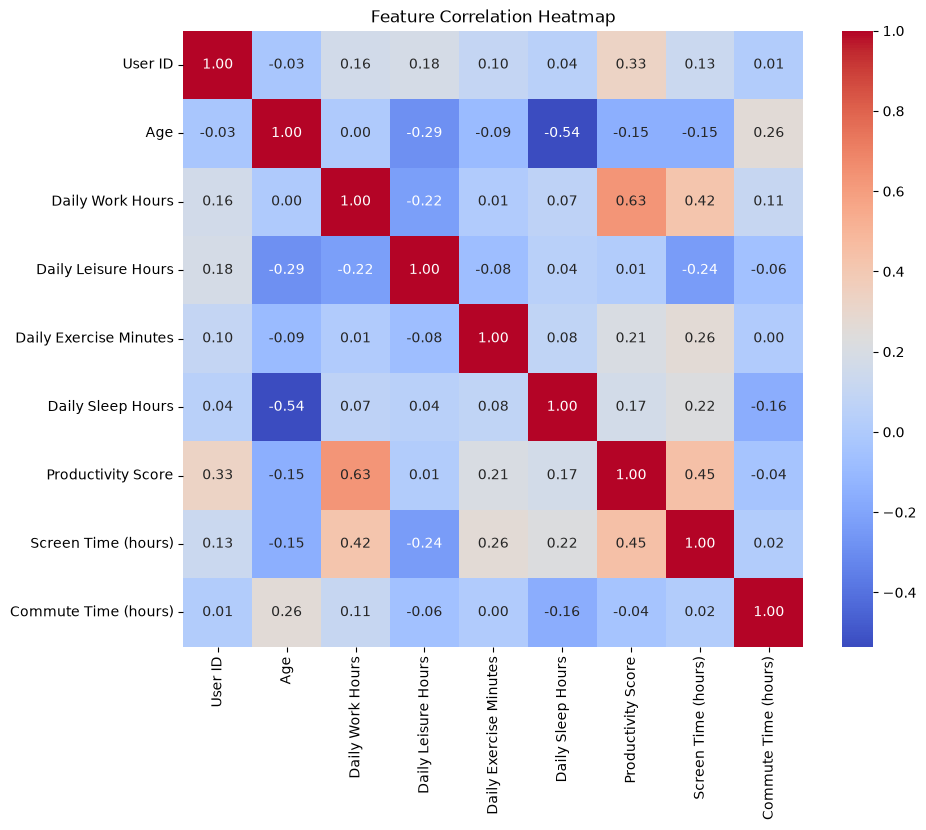

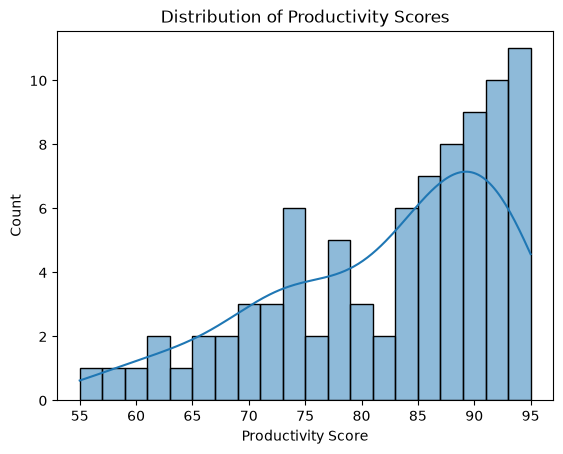

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

sns.histplot(df['Productivity Score'], bins=20, kde=True)
plt.title("Distribution of Productivity Scores")
plt.show()

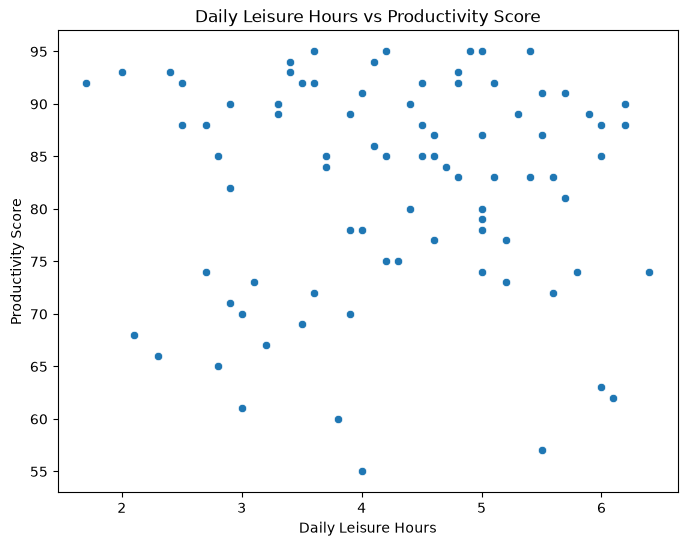

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Daily Leisure Hours', y='Productivity Score', data=df)
plt.title('Daily Leisure Hours vs Productivity Score')
plt.show()

Prepare data

In [15]:
X = df.drop(columns=['Productivity Score', 'User ID'])
Y = df['Productivity Score']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training shapes: X={x_train.shape}, y={y_train.shape}")

Training shapes: X=(68, 7), y=(68,)


In [16]:
mmscaler=MinMaxScaler(feature_range=(0,1))

x_train=mmscaler.fit_transform(x_train)
x_test=mmscaler.fit_transform(x_test)
x_train=pd.DataFrame(x_train)
x_test=pd.DataFrame(x_test)  

Training models

In [17]:
modelRFR = RandomForestRegressor()
modelDTR = DecisionTreeRegressor()
modelLR = LinearRegression()
modelKNR = KNeighborsRegressor(n_neighbors=4)
modelSVR = SVR()

In [21]:
models = [modelRFR, modelDTR, modelLR, modelKNR, modelSVR]

for model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    print("Model name: ", model)
    
    print("MSE", mean_squared_error(y_pred, y_test))
    print("MAE", mean_absolute_error(y_pred, y_test))
    print("R2_score", r2_score(y_pred, y_test))
    print("=======================================")

Model name:  RandomForestRegressor()
MSE 67.79985294117647
MAE 6.255882352941176
R2_score -0.09968254820966993
Model name:  DecisionTreeRegressor()
MSE 59.94117647058823
MAE 5.235294117647059
R2_score 0.5395513263516027
Model name:  LinearRegression()
MSE 115.56340880951731
MAE 8.00345412043029
R2_score -0.9573418583805471
Model name:  KNeighborsRegressor(n_neighbors=4)
MSE 78.21691176470588
MAE 7.073529411764706
R2_score -1.1696421072838303
Model name:  SVR()
MSE 194.68951110072248
MAE 10.083909677102952
R2_score -57.448053567398844


DecisionTreeRegression performs better than other models